# ⚡ 用 vLLM-Hook 抽取表征，重跑 PII 层级探针

数据集、探针、融合、对照、词袋基线**全部沿用现有实验**，只把「从模型里取表征」这一步
从 HuggingFace 的 PyTorch forward hook 换成 [IBM/vLLM-Hook](https://github.com/IBM/vLLM-Hook)。

## 先说结论：能做，但要知道它解决的是什么问题

**能做的部分已核实**（读源码而非猜测）：

| 需求 | vLLM-Hook 是否满足 |
|---|---|
| 取**全部 36 层**，不只是最后一层 | ✅ 配置里 `"layers": [1..36]` 任意指定 |
| 每个词元的表征（好做均值池化） | ✅ `mode: "all_tokens"` 返回 `(seq_len, hidden)` |
| 末位词元表征（实验四那种） | ✅ `mode: "last_token"` 直接返回 `(hidden,)` |
| 只做前向、不真的生成 | ✅ 捕获发生在 **prefill** 阶段 |
| 离线批处理，不必起服务 | ✅ `HookLLM` 直接用 |
| 与 HuggingFace 的数值一致 | ⚠️ **理论上一致，必须实测**（见下） |

**一个关键的正确性细节**：vLLM 把残差加法融合进了下一层的归一化，所以它的 decoder block
返回的是 `(hidden_states, residual)`——**残差还没相加**。朴素捕获会得到与
HuggingFace `output_hidden_states` **不同**的张量。vLLM-Hook 在
`probe_hidden_states_worker.py` 里做了 `hidden = output[0] + output[1]` 把残差加回去，
层号也按 1-based 对齐。所以理论上一致——但这正是本 notebook 第一个 cell 要实测的东西。

## 但它不是当前的瓶颈

看实验一A 的实际耗时分布：

| 阶段 | 耗时 | 占比 |
|---|---|---|
| **抽取表征** | ~3 分钟 | **约 10%** |
| 逐层 L1 探针 | 2 分 33 秒 | 9% |
| **打乱标签对照探针** | **22 分 26 秒** | **80%** |

**抽取只占一成。** 换成 vLLM 最多省下两三分钟，而真正的瓶颈是对照探针的 L1 拟合，
那是 CPU 上的事，与推理引擎无关。

## 那什么时候它才真正有价值

1. **更大的模型 / 更多的数据**——吞吐优势随规模放大；
2. **生成时逐词元探测**——vLLM-Hook 在 decode 阶段同样挂钩，
   而 HF 那条路要做同样的事必须对每个前缀重跑一次模型；
3. **和真实的 vLLM 服务同栈**——如果守卫要部署在 vLLM 上，
   用同一套 hook 抽特征就不存在训练/推理两套代码的偏差。

第 2 点是这个项目此前搁置的方向，也是这条路径最有意思的地方。


## 步骤 1：预检

vLLM 对运行时环境比一般库挑剔得多。这个 cell 一次查清三件事，**不满足就别往下装**：

| 检查项 | 为什么重要 |
|---|---|
| Python 版本 | vllm 0.21 要求 `<3.15`；vllm 0.11 要求 `<3.14` |
| GPU 算力 | T4 是 7.5：**不支持 bfloat16**，也没有 FlashAttention（会回退，能跑但慢） |
| **CUDA 大版本** | **最容易踩的坑**：Colab 的生态是 cu12，而新版 vLLM 钉死的 torch 是 cu13 构建 |


In [9]:
import platform, subprocess, sys, glob, os

print("Python:", platform.python_version())
try:
    import torch
    print("torch:", torch.__version__, "| torch 编译时的 CUDA:", torch.version.cuda)
    if torch.cuda.is_available():
        cc = torch.cuda.get_device_capability(0)
        print("GPU:", torch.cuda.get_device_name(0), f"| 算力 {cc[0]}.{cc[1]}",
              "| bfloat16:", "支持" if cc[0] >= 8 else "不支持（必须用 float16）")
        print("显存:", f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB")
    else:
        print("⚠️ 没有可用 GPU —— vLLM 无法运行")
except ImportError:
    print("torch: 未安装")

# 系统里实际存在哪些 CUDA runtime，就是 libcudart.so.13 报错的根源
libs = sorted({os.path.basename(p) for p in
               glob.glob('/usr/local/lib/python3.*/dist-packages/nvidia/cuda_runtime/lib/libcudart.so*')
               + glob.glob('/usr/local/cuda*/lib64/libcudart.so*')})
print("\n找到的 CUDA runtime:", libs or "（一个都没有）")

import transformers
from transformers.tokenization_utils_base import PreTrainedTokenizerBase
ok = hasattr(PreTrainedTokenizerBase, "all_special_tokens_extended")
print("transformers:", transformers.__version__,
      "| all_special_tokens_extended:", "有" if ok else "已移除 ← vLLM 0.11 需要它")

try:
    import vllm; print("vLLM:", vllm.__version__)
except ImportError:
    print("vLLM: 未安装")
except Exception as e:
    print("vLLM: 已安装但导入失败 →", type(e).__name__, str(e)[:120])


Python: 3.13.15
torch: 2.8.0+cu128 | torch 编译时的 CUDA: 12.8
GPU: NVIDIA L4 | 算力 8.9 | bfloat16: 支持
显存: 22.0 GiB

找到的 CUDA runtime: ['libcudart.so', 'libcudart.so.12', 'libcudart.so.12.8.90']
transformers: 4.57.6 | all_special_tokens_extended: 有
vLLM: 0.11.0


## 步骤 2：安装

**上一轮就是在这里出的错。** `vLLM-Hook/requirement.txt` 写的是 `vllm>=0.5,<=0.21`，
pip 解析到 **0.21.0**，而它钉死 `torch==2.11.0` —— 那是 **CUDA 13** 构建。
Colab 的生态是 cu12，于是 `import vllm._C` 时报
`libcudart.so.13: cannot open shared object file`。

所以**不能直接用 requirement.txt 装 vllm**，要自己钉版本。下面按代价从低到高给两条路。

| | 做法 | 代价 |
|---|---|---|
| ~~路 A~~ | ~~补上缺失的 CUDA 13 runtime~~ | **实测走不通**：该平台无可用 wheel，构建失败 |
| **路 B** | 降到 `vllm==0.11.0` + `transformers==4.57.6` | 会降级 torch，**必须重启运行时** |

直接跑路 B。

In [10]:
import os
os.chdir('/content')

REPO = 'siren-pii-probing'
if os.path.isdir(REPO):
    !cd $REPO && git fetch -q origin && git reset -q --hard origin/main
else:
    !git clone -q https://github.com/jackyluo-learning/siren-pii-probing.git
!cd /content/$REPO && git log --oneline -1

if not os.path.isdir('/content/vLLM-Hook'):
    !git clone -q https://github.com/IBM/vLLM-Hook.git /content/vLLM-Hook

# 只装 vLLM-Hook 自身与本项目的依赖，**不**让 requirement.txt 去解析 vllm
!pip install -q blake3 openai datasets scikit-learn matplotlib scipy
!pip install -q -e /content/vLLM-Hook/vllm_hook_plugins

# 路 A（补 CUDA 13 runtime）已实测走不通：该平台没有可用 wheel，构建失败。
# 直接用下面的路 B。

%cd /content/siren-pii-probing


df9a2d7 (HEAD -> main, origin/main, origin/HEAD) docs: separate code sync from install, and drop the dead CUDA-13 path
  Preparing metadata (setup.py) ... done
/content/siren-pii-probing


### 验证导入

**这一步不过就不要往下跑**——后面每个 cell 都会以同样的错误失败一次，只是更慢。

In [11]:
import importlib, sys
for m in list(sys.modules):
    if m.startswith(('vllm', 'vllm_hook_plugins')):
        del sys.modules[m]
try:
    import vllm
    print("✅ vLLM", vllm.__version__, "导入成功")
    from vllm_hook_plugins import HookLLM
    print("✅ vllm_hook_plugins 导入成功 —— 可以进入步骤 3")
except Exception as e:
    print("❌ 仍然失败 →", type(e).__name__)
    print("  ", str(e)[:200])
    print("\n→ 跑下面的『路 B』，然后【重启运行时】，再从步骤 1 重新开始。")


✅ vLLM 0.11.0 导入成功
INFO 08-27 22:42:39 [__init__.py:216] Automatically detected platform cuda.
❌ 仍然失败 → RuntimeError
   Tried to register an operator (vllm::all_reduce(Tensor tensor, str group_name) -> Tensor) with the same name and overload name multiple times. Each overload's schema should only be registered with a s

→ 跑下面的『路 B』，然后【重启运行时】，再从步骤 1 重新开始。


### 路 B（仅在上面失败时跑）

降到 `vllm==0.11.0`（钉 `torch==2.8.0`，CUDA 12 构建，与 Colab 的 cu12 生态一致），
**同时把 transformers 钉回 4.x**。

第二个钉子是第一轮踩出来的：vLLM 0.11 的分词器缓存要读
`tokenizer.all_special_tokens_extended`，而 **transformers v5 的重构把这个属性删了**。
vLLM 只声明 `transformers>=4.55.2`、没有上限，所以 pip 会留下 Colab 预装的 v5，
然后在 `HookLLM(...)` 构造时——**模型都下完了才**——抛
`AttributeError: Qwen2Tokenizer has no attribute all_special_tokens_extended`。

`4.57.6` 是 4.x 最后一版，Qwen3 从 4.51 起就支持，够用。

**代价**：会把 Colab 预装的 torch 降级，装完**必须重启运行时**（菜单 → 代码执行程序 → 重新启动），
否则进程里还是旧的 torch。重启后从步骤 1 重跑一遍确认。

In [12]:
!pip install "vllm==0.11.0" "transformers==4.57.6" 2>&1 | tail -6
print()
print("=" * 60)
print("装完了。现在【必须重启运行时】：菜单 → 代码执行程序 → 重新启动")
print("重启后从步骤 1 开始重跑（步骤 2 会跳过已装的东西，很快）。")
print("=" * 60)



装完了。现在【必须重启运行时】：菜单 → 代码执行程序 → 重新启动
重启后从步骤 1 开始重跑（步骤 2 会跳过已装的东西，很快）。


### 同步代码（每次跑实验前都执行）

**这个 cell 只做 `git`，不装任何东西**，几秒钟。

单独拆出来是因为步骤 2 混着 pip 安装：重跑它很慢，而代码是会频繁更新的。
**任何一次跑实验之前都先执行这个 cell**，否则跑的是上一次拉下来的旧代码。

In [18]:
%cd /content/siren-pii-probing
!git fetch -q origin && git reset -q --hard origin/main
!git log --oneline -1


/content/siren-pii-probing
04c66cf (HEAD -> main, origin/main, origin/HEAD) fix: stop fragmenting the GPU and filling /dev/shm during extraction


## 步骤 3（必做）：数值一致性检验

**这一步不能跳过。** 两个推理引擎可以在 dtype、读取位置、残差是否相加、
padding 怎么屏蔽上各不相同——**每一项都会改变数值，而且都不会报错**。

这个 cell 取 16 条真实的任务文本，用两条路径各抽一次，逐层比对余弦相似度和相对差。

判读标准：

- fp16 与 fp32 的差异通常在 **1e-3** 量级，余弦相似度应 **> 0.999**；
- 若余弦明显低于 0.999，**不要继续**——先查 dtype、`max_model_len` 是否截断、层号是否对齐。

跑完会写出 `pii_vllm_parity.json`。

In [14]:
!PYTHONPATH=.:examples python -u examples/run_pii_vllm.py \
    --task parity --model "Qwen/Qwen3-4B" --parity-n 16 --max-model-len 128


SIREN on PII via vLLM-Hook — task=parity | model=Qwen/Qwen3-4B | 36 层 | pooling=mean

用 16 条真实任务文本（其中 0 条达到或超过 128 词元的截断上限），两条路径各抽一次并对比 ...

⚠️ 没有样本触及截断上限，这一轮检验覆盖不到边界情况。

Loading 'Qwen/Qwen3-4B' on cuda ...
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100% 3/3 [00:02<00:00,  1.13it/s]
Detected 36 transformer layers.
  已释放 HuggingFace 模型，空闲显存回到 14.3 GiB
INFO 08-27 22:43:18 [__init__.py:216] Automatically detected platform cuda.
  显存账目: 总 22.0 GiB → vLLM 预留 13.7 GiB（权重+KV）, 余下 8.4 GiB 供 hook 缓存
INFO 08-27 22:43:20 [utils.py:233] non-default args: {'trust_remote_code': True, 'download_dir': './cache/', 'dtype': torch.float16, 'max_model_len': 132, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.62, 'disable_log_stats': True, 'enforce_eager': True, 'worker_extension_cls': 'vllm_hook_plugins.workers.probe_hidden_states_worker.ProbeHiddenStatesWorker', 'model': 'Qwen/Qwen3-4B'}
The argument `trust_remote_code` is to be used with Auto classes. It ha

## 步骤 4：用 vLLM 路径跑实验一A

与 HuggingFace 版的实验一A **完全同一个任务**：同样的数据、同样的留出语料
（训练 dolly / 验证 ag_news / 测试 banking77）、同样的 C 网格与 η、同样的对照探针。
**唯一的差别是表征从哪来。**

所以结果可以直接和报告里的实验一A 并排读：

| | 实验一A（HuggingFace） |
|---|---|
| 词袋地板线 | 0.7851 |
| 最佳单层 | 0.9161（L4） |
| 跨层融合 | 0.8391 |
| 抽取耗时 | ~3 分钟 |

如果一致性检验通过，这一版的数字应该**非常接近**上表；差异大就说明抽取路径有问题，
而不是发现了什么新东西。

SIREN on PII via vLLM-Hook — task=presence-merged | model=Qwen/Qwen3-4B | 36 层 | pooling=mean
    干净负样本 banking77   :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_instr :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_resp  :  1500 条（词数 13-40，已过正则筛）
    干净负样本 ag_news     :  1500 条（词数 13-40，已过正则筛）
二分类任务「是否含 PII」：正样本来自 ai4privacy，负样本来自 ['ag_news', 'banking77', 'dolly_instr', 'dolly_resp']
  留出语料: 训练负样本=['dolly_instr', 'dolly_resp'] | 验证负样本=ag_news | 测试负样本=banking77
  验证与测试各用一个未见语料，C 与 alpha_l 才有区分度，且不会调到测试语料上
  ⚠️ 跨语料任务的 TF-IDF 词袋下限实测 0.981（同源任务仅 0.755），请把探针分数与词袋基线并列解读

数据划分: train 6000 / val 1656 / test 1656 | 类别数 2

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.7851
INFO 08-27 22:53:16 [__init__.py:216] Automatically detected platform cuda.
  显存账目: 总 22.0 GiB → vLLM 预留 13.7 GiB（权重+KV）, 余下 8.4 GiB 供 hook 缓存
INFO 08-27 22:53:22 [utils.py:233] non-default args: {'trust_remote_code': True, 'download_dir': './cache/', 'dtype': torch.float16, 'max_model_len': 132, 'enable_prefix_caching': F

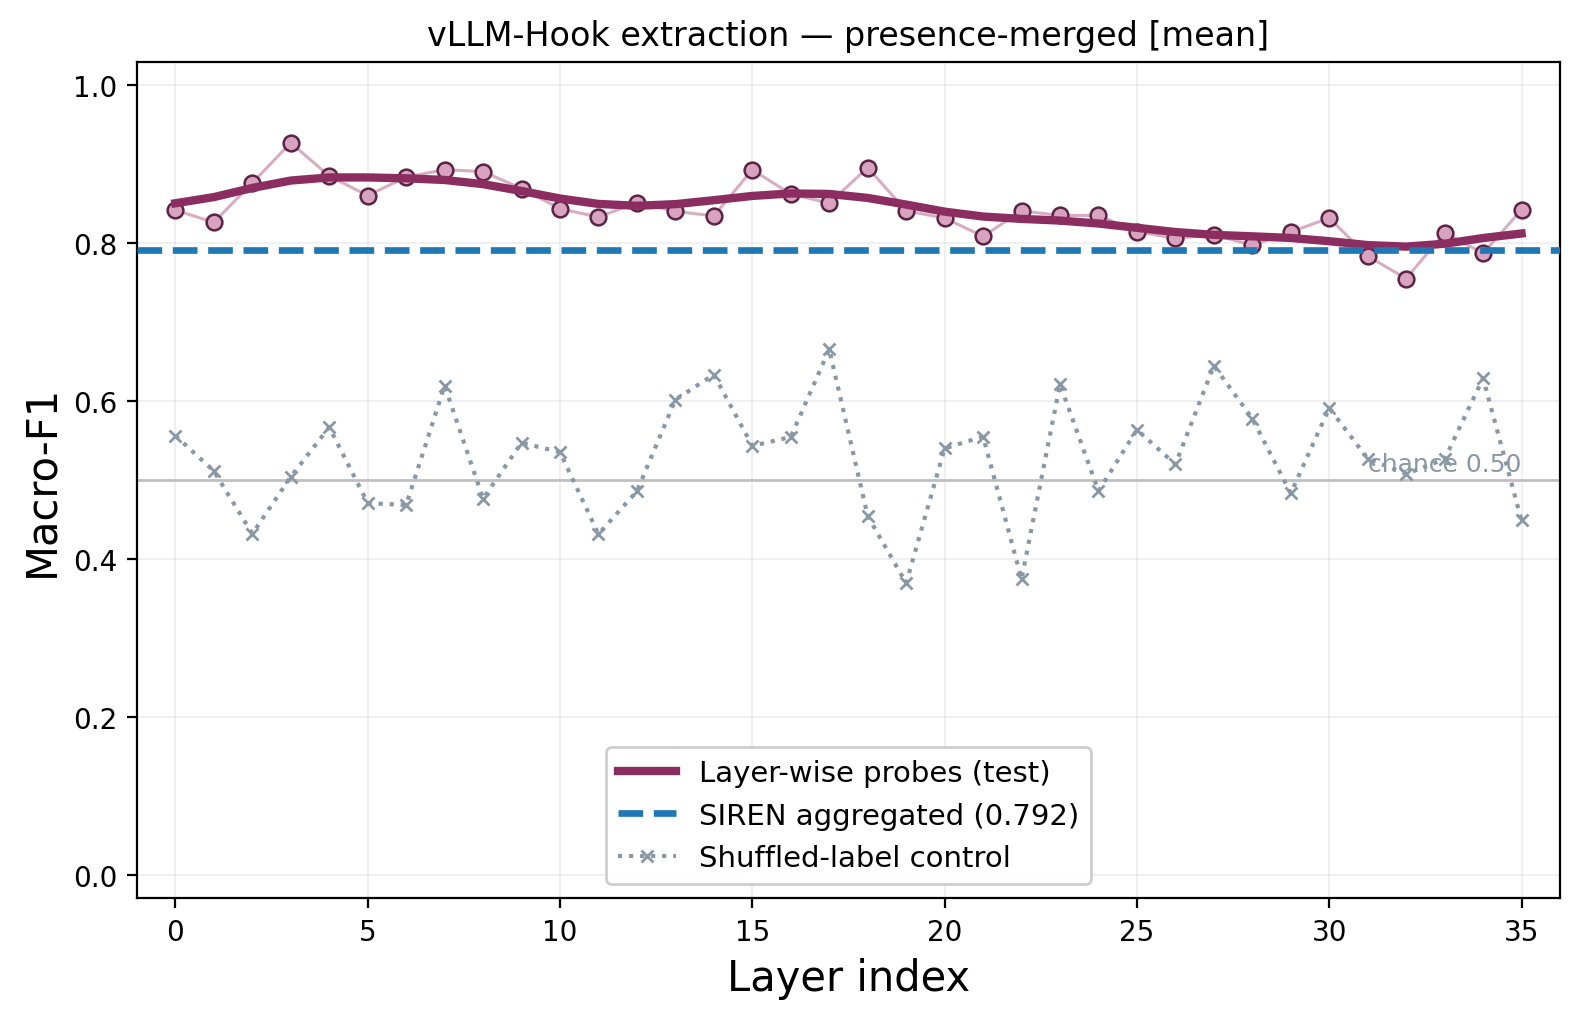

In [19]:
!PYTHONPATH=.:examples python -u examples/run_pii_vllm.py \
    --task presence-merged --holdout-source banking77 \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 \
    --max-model-len 128 --out-prefix pii_vllm

from IPython.display import Image, display
display(Image('pii_vllm_presence-merged_layers.png'))


## 步骤 5：末位词元池化（对应实验四）

`--pooling last` 走 vLLM-Hook 的 `last_token` 模式。

这里有个附带的好处：HF 那条路取末位词元必须按 `attention_mask` 定位真正的最后一个真实词元
（分词器右侧补齐，直接取 `[-1]` 会取到填充符，且不会报错）。
**vLLM 不做 padding**，`hidden[end-1]` 天然就是最后一个真实词元，这个陷阱不存在。

HuggingFace 版实验四的结果：最佳单层 0.8685（L5），跨层融合 0.6223。

In [20]:
!PYTHONPATH=.:examples python -u examples/run_pii_vllm.py \
    --task presence-merged --holdout-source banking77 --pooling last \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 \
    --max-model-len 128 --out-prefix pii_vllm

from IPython.display import Image, display
display(Image('pii_vllm_presence-merged_last_layers.png'))


SIREN on PII via vLLM-Hook — task=presence-merged | model=Qwen/Qwen3-4B | 36 层 | pooling=last
    干净负样本 banking77   :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_instr :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_resp  :  1500 条（词数 13-40，已过正则筛）
    干净负样本 ag_news     :  1500 条（词数 13-40，已过正则筛）
二分类任务「是否含 PII」：正样本来自 ai4privacy，负样本来自 ['ag_news', 'banking77', 'dolly_instr', 'dolly_resp']
  留出语料: 训练负样本=['dolly_instr', 'dolly_resp'] | 验证负样本=ag_news | 测试负样本=banking77
  验证与测试各用一个未见语料，C 与 alpha_l 才有区分度，且不会调到测试语料上
  ⚠️ 跨语料任务的 TF-IDF 词袋下限实测 0.981（同源任务仅 0.755），请把探针分数与词袋基线并列解读

数据划分: train 6000 / val 1656 / test 1656 | 类别数 2

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.7851
INFO 08-27 23:27:49 [__init__.py:216] Automatically detected platform cuda.
  显存账目: 总 22.0 GiB → vLLM 预留 13.7 GiB（权重+KV）, 余下 8.4 GiB 供 hook 缓存
INFO 08-27 23:27:57 [utils.py:233] non-default args: {'trust_remote_code': True, 'download_dir': './cache/', 'dtype': torch.float16, 'max_model_len': 132, 'enable_prefix_caching': F

FileNotFoundError: No such file or directory: 'pii_vllm_presence-merged_last_layers.png'

FileNotFoundError: No such file or directory: 'pii_vllm_presence-merged_last_layers.png'

<IPython.core.display.Image object>

## 步骤 6：两条路径并排对比

把 vLLM 版和 HuggingFace 版的逐层曲线画在一起。**它们应该几乎重合**——
这个 cell 的作用不是发现差异，而是确认没有差异。

In [17]:
import json, glob, numpy as np, matplotlib.pyplot as plt

def load(pattern):
    hits = sorted(glob.glob(pattern))
    return json.load(open(hits[-1])) if hits else None

vl = load('pii_vllm_presence-merged_results.json')
hf = load('pii_presence_merged_ho_banking77_results.json')

if not (vl and hf):
    print("缺少结果文件。需要先跑本 notebook 的步骤 4，"
          "以及主 notebook 里 HuggingFace 版的实验一A。")
else:
    layers = sorted(int(k) for k in vl['test_f1'])
    a = np.array([hf['test_f1'][str(l)] for l in layers])
    b = np.array([vl['test_f1'][str(l)] for l in layers])
    fig, ax = plt.subplots(figsize=(8, 4.6), dpi=160)
    ax.plot(layers, a, label='HuggingFace forward hook', linewidth=2.2, color='#0E6A6E')
    ax.plot(layers, b, label='vLLM-Hook', linewidth=2.2, color='#B07A2E', linestyle='--')
    ax.axhline(hf['lexical_baseline'], color='#9A5518', linestyle=':', linewidth=1.4)
    ax.set_xlabel('Layer index'); ax.set_ylabel('Macro-F1')
    ax.set_title('Same task, same probes — only the extraction path differs')
    ax.grid(alpha=.3); ax.legend()
    plt.tight_layout(); plt.show()

    d = np.abs(a - b)
    print(f"逐层测试 Macro-F1 的绝对差：均值 {d.mean():.4f}  最大 {d.max():.4f}（L{layers[int(d.argmax())]}）")
    print(f"最佳单层   HF {a.max():.4f} (L{layers[int(a.argmax())]})  |  vLLM {b.max():.4f} (L{layers[int(b.argmax())]})")
    print(f"跨层融合   HF {hf['siren_test_f1']:.4f}  |  vLLM {vl['siren_test_f1']:.4f}")
    print(f"抽取耗时   vLLM {vl.get('extract_seconds', float('nan')):.0f}s")
    print()
    print("差异应在 0.01 量级以内（fp16 舍入 + 探针拟合的随机性）。"
          "若明显更大，回到步骤 3 的一致性检验找原因。")


缺少结果文件。需要先跑本 notebook 的步骤 4，以及主 notebook 里 HuggingFace 版的实验一A。


## 已知限制

- **抽取不是瓶颈。** 本 notebook 优化的是整条流水线里约一成的耗时，
  真正的大头是打乱标签对照探针的 L1 拟合（CPU，与推理引擎无关）。
- **显存是 T4 上的硬约束。** hook 缓存**驻留在 GPU 上**直到取回，
  `all_tokens` 模式下占 `块大小 × 36 层 × 序列长 × 2560 维 × 2 字节`。
  实测在 T4（14.56 GiB）上：Qwen3-4B 权重约 7.5 GiB，vLLM 按 `--gpu-mem` 再预留一块，
  剩下的才归 hook 缓存。第一轮固定块大小 32 + `max_model_len 512` 就要 3.36 GiB，
  而当时只剩 1.96 GiB → OOM。现在 `--chunk-size 0` 会按空闲显存自动决定。
- **`--max-model-len` 必须与 HF 路径的 `--max-length` 一致（都是 128）。**
  这是正确性要求不是省显存：截断点不同 = 两条路径吃到不同的词元序列，
  一致性检验必然对不上，哪怕抽取逻辑完全正确。
- **依赖是最大的摩擦点，且和本实验无关。** 实测 Colab（Python 3.13 + T4 + cu12 生态）踩了**两个**坑：
  1. 按 `requirement.txt` 装 → `vllm==0.21.0` → 拖来 `torch==2.11.0`（cu13）→ `libcudart.so.13` 找不到。
     补装 `nvidia-cuda-runtime-cu13` **也不行**（该平台无可用 wheel，构建失败）。
  2. 降到 `vllm==0.11.0` 后导入通过，但构造引擎时报
     `Qwen2Tokenizer has no attribute all_special_tokens_extended`
     ——transformers v5 删了这个属性，而 vLLM 0.11 要读它，且只声明 `>=4.55.2` 没有上限。
  两个坑都必须自己钉版本（`vllm==0.11.0` + `transformers==4.57.6`）。
  这类问题会随 Colab 镜像变化反复出现，与实验结论无关。
- **T4 的限制。** 算力 7.5，**不支持 bfloat16**（本项目已固定用 float16），
  也没有 FlashAttention，vLLM 会回退到较慢的实现——吞吐优势因此打折。
- **本地未验证。** 编写这套代码的机器没有 CUDA，无法跑通 vLLM，
  所以步骤 3 的一致性检验是**必须**的，不是可选的。

## 下一步值得做的

真正能发挥 vLLM-Hook 长处的是**生成时逐词元探测**：让模型真的生成回复，
在 decode 的每一步取表征、打分，看标识符是在第几个词元被认出来的。
HF 那条路要做同样的事，必须对每个前缀重跑一次模型——O(T²)；
而 vLLM-Hook 在 decode 时本来就在挂钩，是 O(T)。
